In [1]:
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm
from scipy.stats import norm
from scipy.optimize import minimize

In [2]:
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import warnings

In [4]:
sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu

In [5]:
RNG = np.random.default_rng(42)

In [6]:
years_verif = np.arange(2000, 2026)
years_train = np.arange(1968, 2000)

data_dir = '/glade/derecho/scratch/ksha/EPRI_data/METRICS/'
ds_target = xr.open_zarr(os.path.join(data_dir, 'STN_ERA5_ALL_20260604.zarr'))
ds_input  = xr.open_zarr(os.path.join(data_dir, 'STN_CESM_ALL_20260604.zarr'))

# ds_target_hist for determine percentiles
ds_target_hist = ds_target.sel(valid_year=years_train)

# raw forecast as reference
ds_raw_pred = ds_input.sel(init_year=np.arange(2000, 2021))

# ds_target with dims of `(valid_year: 26)`, valid_year = init_year + lead_year, up to 2025
ds_target = ds_target.sel(valid_year=years_verif)

# ====================================================================== #
# EMOS
# ====================================================================== #
save_dir = '/glade/derecho/scratch/ksha/EPRI_data/PP_calib/EMOS/'
ds_dress = xr.open_zarr(save_dir+'Dress_4param.zarr')
ds_dress_t = xr.open_zarr(save_dir+'Dress_Trend.zarr')
ds_dress_qm = xr.open_zarr(save_dir+'Dress_QM.zarr')

ds_calib = xr.open_zarr(save_dir+'Calib_4param.zarr')
ds_calib_t = xr.open_zarr(save_dir+'Calib_Trend.zarr')

ds_dress_qm_mean = ds_dress_qm.mean('member')
ds_dress_qm_mean = ds_dress_qm_mean.rename({v: f"{v}_mu" for v in ds_dress_qm_mean.data_vars})

ds_dress_qm_std = ds_dress_qm.std('member')
ds_dress_qm_std = ds_dress_qm_std.rename({v: f"{v}_sigma" for v in ds_dress_qm_std.data_vars})

ds_calib_qm = xr.merge([ds_dress_qm_mean, ds_dress_qm_std])

# ds_dress_all with dims of `(init_year: 21, lead_year: 10, member: 50)` for all post-processed variables
ds_dress_EMOS = xr.merge([ds_dress, ds_dress_t, ds_dress_qm])

# ds_calib_all with dims of `(init_year: 21, lead_year: 10)` for non-precip (Gaussian distributed) variables, each variable has suffix of `_mu` and `_sigma` for mean and std.
ds_calib_EMOS = xr.merge([ds_calib, ds_calib_t, ds_calib_qm])

# ====================================================================== #
# BMA
# ====================================================================== #
save_dir = '/glade/derecho/scratch/ksha/EPRI_data/PP_calib/BMA/'
ds_dress_bma = xr.open_zarr(save_dir+'Dress.zarr')
ds_calib_bma = xr.open_zarr(save_dir+'Calib.zarr')
ds_dress_qm_bma = xr.open_zarr(save_dir+'Dress_QM.zarr').rename({'dressed_member': 'member'})
ds_dress_bma = ds_dress_bma.rename({'dressed_member': 'member'})

qm_mu = ds_dress_qm_bma.mean('member').rename({v: f"{v}_mu" for v in ds_dress_qm_bma.data_vars})
qm_sg = ds_dress_qm_bma.std('member', ddof=1).rename({v: f"{v}_sigma" for v in ds_dress_qm_bma.data_vars})

ds_calib_BMA = xr.merge([ds_calib_bma, qm_mu, qm_sg])
ds_dress_BMA = xr.merge([ds_dress_bma, ds_dress_qm_bma])

In [7]:
# plt.plot(ds_calib_all['Fairbanks_T2_1d_max_mu'].values[0, :])
# plt.plot(ds_raw_pred['Fairbanks_T2_1d_max'].mean('member').values[0, :])

In [8]:
# plt.plot(ds_calib_all['Fairbanks_T2_1d_max_sigma'].values[0, :])
# plt.plot(ds_raw_pred['Fairbanks_T2_1d_max'].std('member').values[0, :])

In [9]:
sources = {
    'EMOS': (ds_calib_EMOS, ds_dress_EMOS),
    'BMA' : (ds_calib_BMA,  ds_dress_BMA),
    'Raw' : (ds_raw_pred,   ds_raw_pred),   # same ds twice -> ensemble branch
}

my_colors = gu.ksha_color_set_summon(color_set=0)
# cyan = my_colors['cyan']
cyan = np.array([0.4, 0.8, 1, 1])
blue = my_colors['blue']
red = my_colors['red']
orange = my_colors['orange']

In [38]:
# ----------------------------------------------------------------------
# helpers: alignment
# ----------------------------------------------------------------------
def align_obs(ds_fcst, ds_target, var_obs, years_verif):
    """
    Build obs array on the forecast (init_year, lead_year) grid using
    valid_year = init_year + lead_year. Cells outside years_verif (or missing
    in ds_target) are NaN.
 
    Returns
    -------
    obs   : np.ndarray (n_init, n_lead)
    leads : np.ndarray of lead_year values
    """
    init = np.asarray(ds_fcst['init_year'].values)
    lead = np.asarray(ds_fcst['lead_year'].values)
    vy = init[:, None] + lead[None, :]
 
    tgt_years = np.asarray(ds_target['valid_year'].values)
    tgt_vals = np.asarray(ds_target[var_obs].values)
    lut = {int(y): v for y, v in zip(tgt_years, tgt_vals)}
 
    obs = np.full(vy.shape, np.nan)
    ok = np.isin(vy, years_verif)
    for i in range(vy.shape[0]):
        for l in range(vy.shape[1]):
            if ok[i, l] and int(vy[i, l]) in lut:
                obs[i, l] = lut[int(vy[i, l])]
    return obs, lead
 
 
def extract_source(var_, kind, ds, common_inits=None):
    """
    Returns dict with:
      mu     (init, lead)            ensemble mean / Gaussian mu
      sigma  (init, lead)            spread (member std, ddof=1 / Gaussian sigma)
      ens    (init, lead, member) or None
      ds     subset dataset (for coords)
    """
    if common_inits is not None:
        ds = ds.sel(init_year=ds['init_year'].isin(common_inits))
 
    if kind == 'gaussian':
        mu = ds[f'{var_}_mu'].transpose('init_year', 'lead_year').values
        sg = ds[f'{var_}_sigma'].transpose('init_year', 'lead_year').values
        sg = np.where(sg > 0, sg, np.nan)
        return dict(kind=kind, mu=mu, sigma=sg, ens=None, ds=ds)
    elif kind == 'ensemble':
        ens = ds[var_].transpose('init_year', 'lead_year', 'member').values
        mu = np.nanmean(ens, axis=-1)
        sg = np.nanstd(ens, axis=-1, ddof=1)
        return dict(kind=kind, mu=mu, sigma=sg, ens=ens, ds=ds)
    raise ValueError(f"unknown kind: {kind}")
 
 
# ----------------------------------------------------------------------
# helpers: metrics
# ----------------------------------------------------------------------
def _corr(a, b):
    """Pearson correlation with NaN handling. (ACC: a constant climatological
    offset does not change correlation, so anomalies are implicit.)"""
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m] - a[m].mean()
    b = b[m] - b[m].mean()
    d = np.sqrt((a * a).sum() * (b * b).sum())
    return float((a * b).sum() / d) if d > 0 else np.nan
 
 
def crps_gaussian(obs, mu, sigma):
    z = (obs - mu) / sigma
    return sigma * (z * (2.0 * norm.cdf(z) - 1.0)
                    + 2.0 * norm.pdf(z) - 1.0 / np.sqrt(np.pi))
 
 
def crps_ensemble(obs, ens):
    """obs (...,), ens (..., M). PWM form: E|X-y| - 0.5 E|X-X'|."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        t1 = np.nanmean(np.abs(ens - obs[..., None]), axis=-1)
        t2 = np.nanmean(np.abs(ens[..., :, None] - ens[..., None, :]),
                        axis=(-2, -1))
    return t1 - 0.5 * t2
 
 
def by_lead(arr2d, func=np.nanmean):
    """Reduce (init, lead) -> (lead,) with a NaN-aware func."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        return np.array([func(arr2d[:, l]) for l in range(arr2d.shape[1])])
 
 
# ----------------------------------------------------------------------
# per-source metric computation
# ----------------------------------------------------------------------
def compute_metrics(var_, kind, ds, ds_target, years_verif, common_inits=None):
    """Per-source deterministic + CRPS metrics on the (init, lead) grid.
 
    Returns a dict with 'leads', 'acc', 'rmse', 'spread', 'crps'.
    """
    src = extract_source(var_, kind, ds, common_inits)
    obs, leads = align_obs(src['ds'], ds_target, var_, years_verif)
 
    out = dict(leads=leads)
    err = src['mu'] - obs
    out['acc'] = np.array([_corr(src['mu'][:, l], obs[:, l])
                           for l in range(len(leads))])
    out['rmse'] = np.sqrt(by_lead(err ** 2))
    out['spread'] = np.sqrt(by_lead(src['sigma'] ** 2))
 
    crps = (crps_gaussian(obs, src['mu'], src['sigma']) if kind == 'gaussian'
            else crps_ensemble(obs, src['ens']))
    out['crps'] = by_lead(np.where(np.isfinite(obs), crps, np.nan))
    return out
 
 
def pick_source(var_, ds_calib_x, ds_dress_x):
    """Gaussian closed forms when `<var>_mu` exists in the calib dataset,
    otherwise the member-based (dressed/raw) ensemble."""
    if f'{var_}_mu' in ds_calib_x.data_vars:
        return ('gaussian', ds_calib_x)
    return ('ensemble', ds_dress_x)
 
 
# ----------------------------------------------------------------------
# small helpers
# ----------------------------------------------------------------------
def _common_init_years(sources):
    """Intersection of init_year over every dataset referenced in `sources`."""
    sets = []
    for pair in sources.values():
        for ds in pair:
            if ds is not None and 'init_year' in ds.coords:
                sets.append({int(y) for y in np.asarray(ds['init_year'].values)})
    return np.array(sorted(set.intersection(*sets))) if sets else None
 
 
def _stack(mv, labels, key):
    """Stack a per-lead metric across labels -> (n_label, n_lead)."""
    return np.array([mv[lab][key] for lab in labels], dtype=float)
 
 
def _nanmin(a, default):
    return float(np.nanmin(a)) if np.isfinite(a).any() else default
 
 
def _nanmax(a, default):
    return float(np.nanmax(a)) if np.isfinite(a).any() else default
 
 
def _alpha_labels(n):
    """Panel tags ('a'), ('b'), ... extended to ('aa'), ('ab'), ... past 26."""
    out = []
    for i in range(n):
        s, j = '', i
        while j >= 0:
            s = chr(97 + j % 26) + s
            j = j // 26 - 1
        out.append(f'({s})')
    return out
 
 
def _hersbach(ens2d, obs1d):
    """Hersbach (2000) CRPS reliability for one lead.
 
    ens2d (n, M) finite ensemble, obs1d (n,) finite obs. Returns the
    reliability term of the CRPS decomposition (>= 0; 0 = perfectly reliable).
    """
    n, M = ens2d.shape
    if n < 2 or M < 2:
        return np.nan
    x = np.sort(ens2d, axis=1)                         # (n, M) ascending
    o = obs1d
    alpha = np.zeros((n, M + 1))
    beta = np.zeros((n, M + 1))
    for i in range(1, M):                              # interior bins x_i .. x_{i+1}
        lo, hi = x[:, i - 1], x[:, i]
        w = hi - lo
        above = o >= hi
        below = o <= lo
        inside = ~above & ~below
        alpha[above, i] = w[above]
        beta[below, i] = w[below]
        alpha[inside, i] = o[inside] - lo[inside]
        beta[inside, i] = hi[inside] - o[inside]
    below0 = o < x[:, 0]                               # outlier bins
    beta[below0, 0] = x[below0, 0] - o[below0]
    aboveM = o > x[:, -1]
    alpha[aboveM, M] = o[aboveM] - x[aboveM, -1]
    abar, bbar = alpha.mean(axis=0), beta.mean(axis=0)
    p = np.arange(M + 1) / M                           # forecast prob per bin
    g = abar + bbar
    with np.errstate(invalid='ignore', divide='ignore'):
        obar = np.where(g > 0, bbar / g, 0.0)          # observed frequency
    return float(np.sum(g * (obar - p) ** 2))
 
 
def _ens_diagnostics(var_, dress_ds, ds_target, years_verif, common_inits):
    """Ensemble diagnostics from a dressed/raw ensemble, evaluated over the
    verifying init years only:
 
        emean  : ensemble-mean RMSE per lead
        spread : ensemble spread = sqrt(mean_init var_member) per lead
        reli   : Hersbach (2000) CRPS reliability per lead
 
    Returns a dict of (n_lead,) arrays plus 'leads'; the three arrays are None
    when the source has no member dimension.
    """
    leads = np.asarray(dress_ds['lead_year'].values)
    if 'member' not in dress_ds[var_].dims:
        return dict(emean=None, spread=None, reli=None, leads=leads)
    src = extract_source(var_, 'ensemble', dress_ds, common_inits)
    obs, leads = align_obs(src['ds'], ds_target, var_, years_verif)
    ens = src['ens']                                   # (n_init, n_lead, M)
    nL = leads.size
    emean = np.full(nL, np.nan)
    spread = np.full(nL, np.nan)
    reli = np.full(nL, np.nan)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        mu = np.nanmean(ens, axis=-1)                  # (n_init, n_lead)
        sig = np.nanstd(ens, axis=-1, ddof=1)          # (n_init, n_lead)
        for l in range(nL):
            o = obs[:, l]
            ok = np.isfinite(o) & np.all(np.isfinite(ens[:, l, :]), axis=-1)
            if ok.sum() < 2:
                continue
            emean[l] = np.sqrt(np.mean((mu[ok, l] - o[ok]) ** 2))
            spread[l] = np.sqrt(np.mean(sig[ok, l] ** 2))
            reli[l] = _hersbach(ens[ok, l, :], o[ok])
    return dict(emean=emean, spread=spread, reli=reli, leads=leads)
 
 
def _bootstrap_acc(var_, sources, ds_target, years_verif, common_inits,
                   n_boot, ci, rng):
    """Bootstrap confidence interval for the ensemble-mean ACC.
 
    Resamples the verification cases (init/valid years) with replacement and
    recomputes the centred correlation. The same resample is shared across
    sources at each lead (paired), so the intervals are comparable between
    methods. Returns (lo, hi, leads) where lo/hi are dict[label] -> (n_lead,)
    arrays giving the ci% percentile interval (NaN where < 3 valid cases).
    """
    labels = list(sources.keys())
    mu, obs, leads = {}, None, None
    for lab in labels:
        kind, ds = pick_source(var_, *sources[lab])
        src = extract_source(var_, kind, ds, common_inits)
        mu[lab] = src['mu']                                  # (n_init, n_lead)
        if obs is None:
            obs, leads = align_obs(src['ds'], ds_target, var_, years_verif)
    nL = leads.size
    lo = {lab: np.full(nL, np.nan) for lab in labels}
    hi = {lab: np.full(nL, np.nan) for lab in labels}
    qlo, qhi = (100.0 - ci) / 2.0, 100.0 - (100.0 - ci) / 2.0
    for l in range(nL):
        valid = np.isfinite(obs[:, l])
        for lab in labels:                                   # shared valid set
            valid = valid & np.isfinite(mu[lab][:, l])
        iv = np.where(valid)[0]
        if iv.size < 3:
            continue
        ob = obs[iv, l]
        bs = rng.integers(0, iv.size, size=(n_boot, iv.size))   # (B, n_valid)
        ob_c = ob[bs] - ob[bs].mean(axis=1, keepdims=True)
        ob_ss = np.einsum('ij,ij->i', ob_c, ob_c)
        for lab in labels:
            mb = mu[lab][iv, l][bs]
            mb_c = mb - mb.mean(axis=1, keepdims=True)
            num = np.einsum('ij,ij->i', mb_c, ob_c)
            den = np.sqrt(np.einsum('ij,ij->i', mb_c, mb_c) * ob_ss)
            with np.errstate(invalid='ignore', divide='ignore'):
                r = np.where(den > 0, num / den, np.nan)
            if np.isfinite(r).any():
                lo[lab][l], hi[lab][l] = np.nanpercentile(r, [qlo, qhi])
    return lo, hi, leads
 
 
# ----------------------------------------------------------------------
# main routine
# ----------------------------------------------------------------------
def verify_variables_grid(
    varnames, sources, ds_target, years_verif, common_inits=None,
    col_width=3.9, row_height=2.5, n_boot=0, ci=99.0, boot_seed=0,
    title_names=['xxx', ] * 24, color_list=['k', ] * 24, show_legend=False,
):
    """
    Parameters
    ----------
    varnames : list[str]
        One row per variable, e.g.
        ['Fairbanks_T2_1d_max', 'Fairbanks_T2_7d_max', 'Fairbanks_T2_30d_max'].
    sources : dict[str, (calib_ds, dress_ds)]
        For each method, a Gaussian/calib dataset and an ensemble/dress dataset;
        `pick_source` selects per variable. For a raw ensemble, pass the same
        dataset twice, e.g. {'Raw': (ds_raw_pred, ds_raw_pred)}.
    ds_target : xr.Dataset
        Verifying obs on the valid_year grid.
    years_verif : array-like
        Valid-year verification window.
    common_inits : array-like or None
        Defaults to the intersection of init_years across all sources.
    col_width, row_height : float
        Inches per column / row. Figure height scales with len(varnames).
    n_boot : int
        Bootstrap resamples for the ensemble-mean ACC confidence interval
        (error bars in panel a). Set to 0 to disable the error bars.
    ci : float
        Confidence level in percent for the ACC interval (default 99 -> the
        0.5-99.5 percentile band).
    boot_seed : int or None
        Seed for the bootstrap RNG (reproducible error bars).
    title_names : list[str]
        Per-row title drawn above the middle column (one entry per variable).
    color_list : list
        Per-source colors, indexed by the order of keys in `sources`.
 
    Returns
    -------
    fig, metrics      # metrics[var][label] == the dict returned by compute_metrics
    """
    nvar = len(varnames)
    labels = list(sources.keys())
    nlab = len(labels)
    bw = 0.8 / nlab                       # grouped-bar width for ACC
    if common_inits is None:
        common_inits = _common_init_years(sources)
    boot_on = bool(n_boot) and n_boot > 0
    rng = np.random.default_rng(boot_seed)
    colors = {lab: color_list[i] for i, lab in enumerate(labels)}
 
    # ---- compute metrics[var][label] --------------------------------
    metrics = {v: {} for v in varnames}
    for v in varnames:
        for lab in labels:
            kind, ds = pick_source(v, *sources[lab])
            metrics[v][lab] = compute_metrics(
                v, kind, ds, ds_target, years_verif, common_inits=common_inits)
 
    # ---- figure & grid ----------------------------------------------
    fig = plt.figure(figsize=(3 * col_width, nvar * row_height))
    gs = gridspec.GridSpec(nvar, 3, figure=fig)
    axes = np.empty((nvar, 3), dtype=object)
    for r in range(nvar):
        for c in range(3):
            axes[r, c] = fig.add_subplot(gs[r, c], sharex=axes[0, c] if r else None)
 
    leads = np.asarray(metrics[varnames[0]][labels[0]]['leads'])
    title_strings = [' Ensemble Mean ACC',
                     ' CRPS and its Reliability Components',
                     ' Ensemble Mean RMSE-to-Spread Ratio']
    title_alph = _alpha_labels(nvar * 3)
    zorders = list(range(nlab + 2, 2, -1))      # first source drawn on top
    count = 0
 
    for r, v in enumerate(varnames):
        ax_acc, ax_crps, ax_rmse = axes[r]
        mv = metrics[v]
        ratio_vals = []                          # collect for panel-(c) y-limits
 
        # bootstrap CI for ensemble-mean ACC (shared resample across sources)
        if boot_on:
            blo, bhi, _ = _bootstrap_acc(
                v, sources, ds_target, years_verif, common_inits,
                int(n_boot), ci, rng)
 
        for k, lab in enumerate(labels):
            m, col = mv[lab], colors[lab]
            ld = np.asarray(m['leads'])
            off = (k - (nlab - 1) / 2.0) * bw
            diag = _ens_diagnostics(v, sources[lab][1], ds_target,
                                    years_verif, common_inits)
 
            # (a) ACC grouped bars (+ bootstrap CI error bars)
            acc_pt = np.asarray(m['acc'], dtype=float)
            if boot_on:
                yerr = np.vstack([acc_pt - blo[lab], bhi[lab] - acc_pt])
                yerr = np.where(np.isfinite(yerr), np.clip(yerr, 0, None), 0.0)
                ax_acc.bar(ld + off, acc_pt, width=bw, color=col, label=lab,
                           edgecolor='none', yerr=yerr, capsize=2,
                           error_kw=dict(elinewidth=0.8, ecolor='0.15',
                                         capthick=0.8))
            else:
                ax_acc.bar(ld + off, acc_pt, width=bw, color=col, label=lab,
                           edgecolor='none')
 
            # (b) total CRPS (solid) + Hersbach reliability (dashed)
            ax_crps.plot(ld, m['crps'], '-o', ms=4, lw=1.6, color=col,
                         zorder=zorders[k])
            if diag['reli'] is not None:
                ax_crps.plot(ld, diag['reli'], '--s', ms=3, lw=1.0, color=col,
                             mfc='none', zorder=zorders[k])
 
            # (c) spread-skill ratio = ensemble-mean RMSE / ensemble spread
            if diag['emean'] is not None:
                ratio = diag['emean'] / np.where(diag['spread'] > 0,
                                                 diag['spread'], np.nan)
            else:
                sp = np.asarray(m['spread'], dtype=float)
                ratio = np.asarray(m['rmse'], dtype=float) / np.where(sp > 0, sp, np.nan)
            ax_rmse.plot(ld, ratio, '-o', ms=4, lw=1.6, color=col)
            ratio_vals.append(np.asarray(ratio, dtype=float))
 
        # reference lines
        ax_acc.axhline(0, color='k', lw=1.5, ls=':')
        ax_rmse.axhline(1.0, color='k', lw=1.5, ls=':')   # perfect spread-skill
 
        # y-limits
        acc_min = _nanmin(_stack(mv, labels, 'acc'), -0.2)
        if boot_on:
            acc_min = min(acc_min, _nanmin(
                np.concatenate([np.asarray(blo[l_], float) for l_ in labels]), -0.2))
        ax_acc.set_ylim(min(0.0, acc_min) - 0.05, 1.05)
 
        crps_max = _nanmax(_stack(mv, labels, 'crps'), 1.0) * 1.5
        ax_crps.set_ylim(-0.1 * crps_max, crps_max)
 
        rv = np.concatenate(ratio_vals) if ratio_vals else np.array([1.0])
        rlo, rhi = min(_nanmin(rv, 1.0), 1.0), max(_nanmax(rv, 1.0), 1.0)
        pad = 0.10 * (rhi - rlo if rhi > rlo else 0.5)
        ax_rmse.set_ylim(rlo - pad, rhi + 3 * pad)
 
        # axes decoration
        last = (r == nvar - 1)
        for c, ax in enumerate(axes[r]):
            ax.set_title(title_alph[count] + title_strings[c], fontsize=10, y=0.8)
            count += 1
            ax = gu.ax_decorate_box(ax)
            ax.set_xlim(leads.min() - 0.8, leads.max() + 0.4)
            ax.xaxis.set_tick_params(labelsize=10)
            ax.yaxis.set_tick_params(labelsize=10)
            ax.tick_params(axis='both', labelleft=True)
            if last:
                ax.tick_params(axis='both', labelbottom=True)
                ax.set_xlabel('Prediction Lead Time [Year]', fontsize=10)
            if c == 1:
                ax.text(0.5, 1.1, title_names[r], fontsize=10, ha='center',
                        va='bottom', transform=ax.transAxes)
 
    # ---- legends ----------------------------------------------------
    # y-anchor in figure fraction: keep a constant ~0.9" gap below the figure
    # top regardless of nvar (0.9" reproduces 0.88 at nvar=3, row_height=2.5).
    # x is horizontal and does not depend on nvar.
    y_leg = 1.0 - 0.515 / (nvar * row_height)
 
    handles, lbls = axes[0, 0].get_legend_handles_labels()
    LG1 = fig.legend(handles, lbls, loc='lower center', ncol=3, fontsize=10,
                     frameon=True, facecolor='white', framealpha=0.8,
                     edgecolor='none', handlelength=1.0,
                     bbox_to_anchor=(0.16, y_leg))
    LG1 = gu.lg_box(LG1)

    if show_legend:
        crps_styles = [Line2D([0], [0], color='0.3', ls='-', lw=1.6),
                       Line2D([0], [0], color='0.3', ls='--', lw=1.2)]
        LG2 = fig.legend(crps_styles, ['CRPS', 'CRPS Rel.'], loc='lower center',
                         ncol=2, fontsize=10, frameon=True, facecolor='white',
                         framealpha=0.8, edgecolor='none', handlelength=1.4,
                         bbox_to_anchor=(0.5, y_leg))
        LG2 = gu.lg_box(LG2)
 
    plt.subplots_adjust(0, 0, 1, 1, hspace=0.35, wspace=0.1)
    return fig, metrics

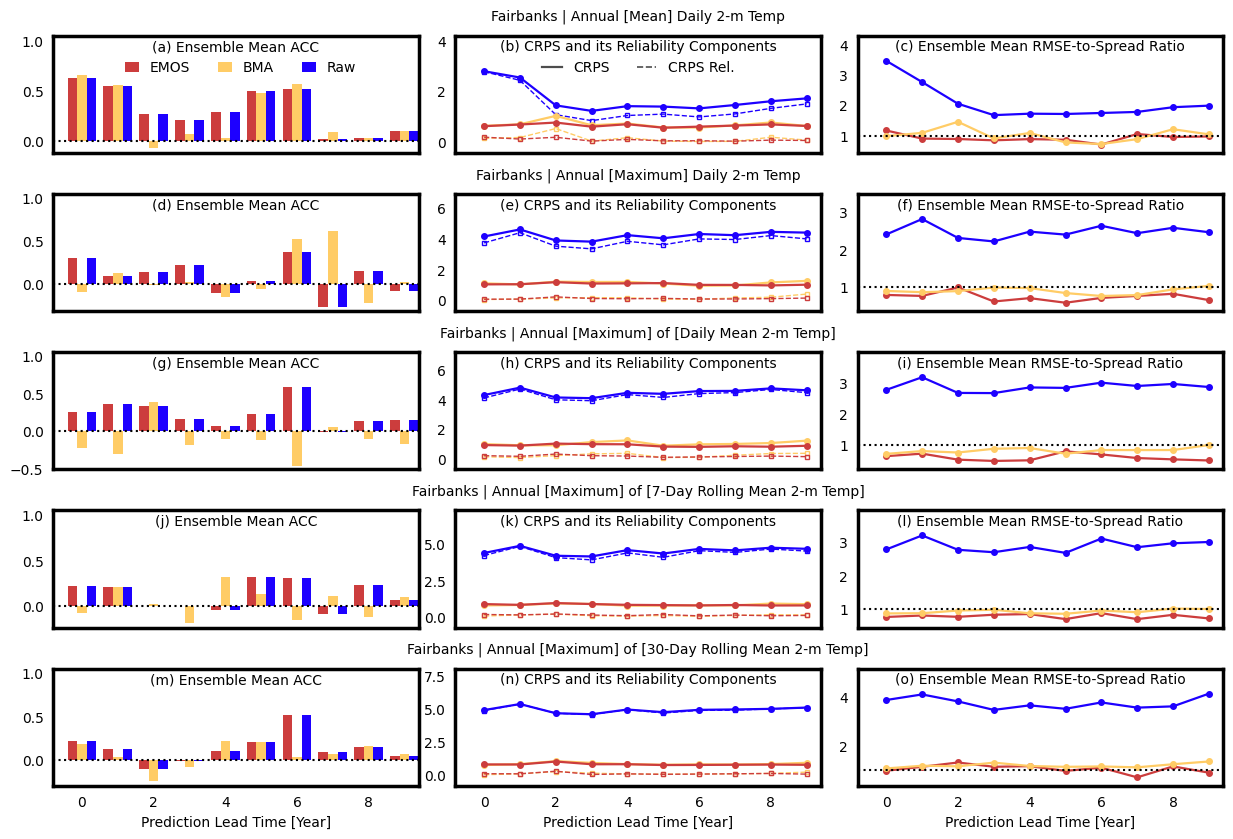

In [39]:
col_width = 3.9
row_height = 1.5
varnames = ['Fairbanks_simple_T2_1d_mean', 'Fairbanks_T2_1h_max', 'Fairbanks_T2_1d_max', 'Fairbanks_T2_7d_max', 'Fairbanks_T2_30d_max'] # ]
title_names = []
for name_ in varnames:
    title_names.append(vars_verif[name_])

color_list = [red, orange, blue,]
fig, metrics = verify_variables_grid(
    varnames, sources, ds_target, years_verif, 
    col_width=col_width, row_height=row_height, 
    title_names=title_names, color_list=color_list, show_legend=True)

/glade/derecho/scratch/ksha/tmp/ipykernel_5634/3940790470.py:50: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(ens, axis=-1)
/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/derecho/scratch/ksha/tmp/ipykernel_5634/3940790470.py:50: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(ens, axis=-1)
/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


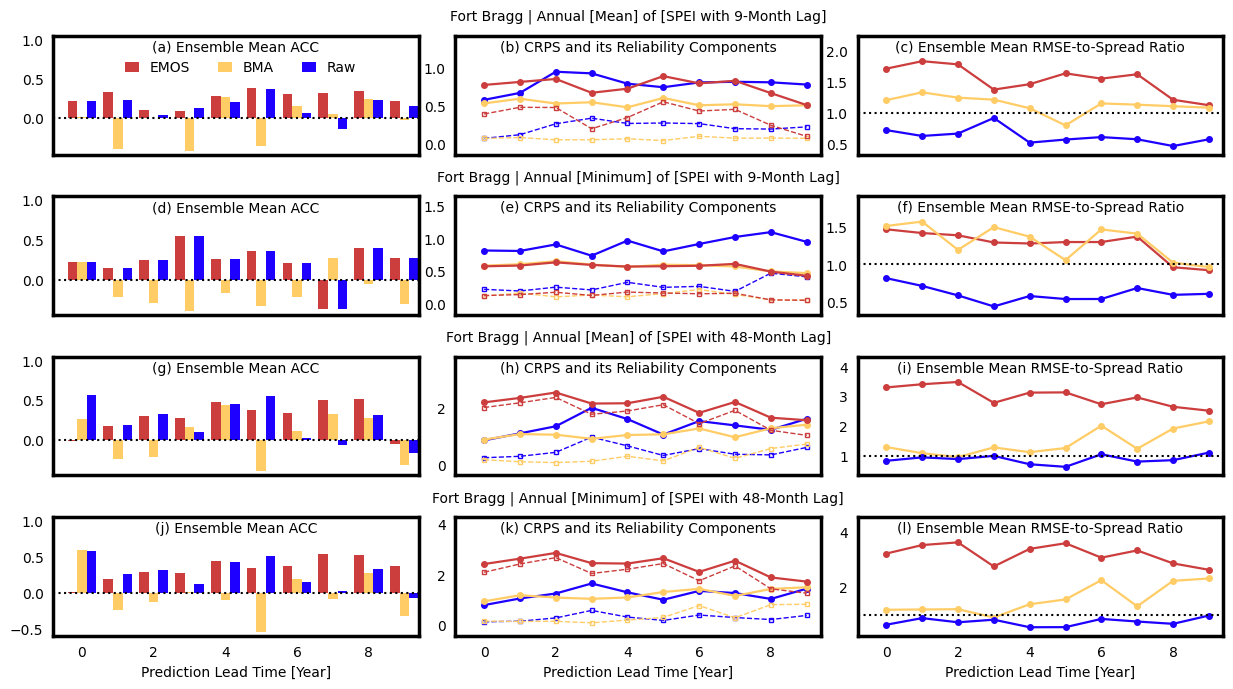

In [40]:
col_width = 3.9
row_height = 1.5
varnames = ['Fort_Bragg_SPEI_09_mean', 'Fort_Bragg_SPEI_09_min', 'Fort_Bragg_SPEI_48_mean', 'Fort_Bragg_SPEI_48_min',] # ]
title_names = []
for name_ in varnames:
    title_names.append(vars_verif[name_])

color_list = [red, orange, blue,]
fig, metrics = verify_variables_grid(
    varnames, sources, ds_target, years_verif, 
    col_width=col_width, row_height=row_height, 
    title_names=title_names, color_list=color_list, show_legend=False)

/glade/derecho/scratch/ksha/tmp/ipykernel_5634/3940790470.py:50: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(ens, axis=-1)
/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/derecho/scratch/ksha/tmp/ipykernel_5634/3940790470.py:50: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(ens, axis=-1)
/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


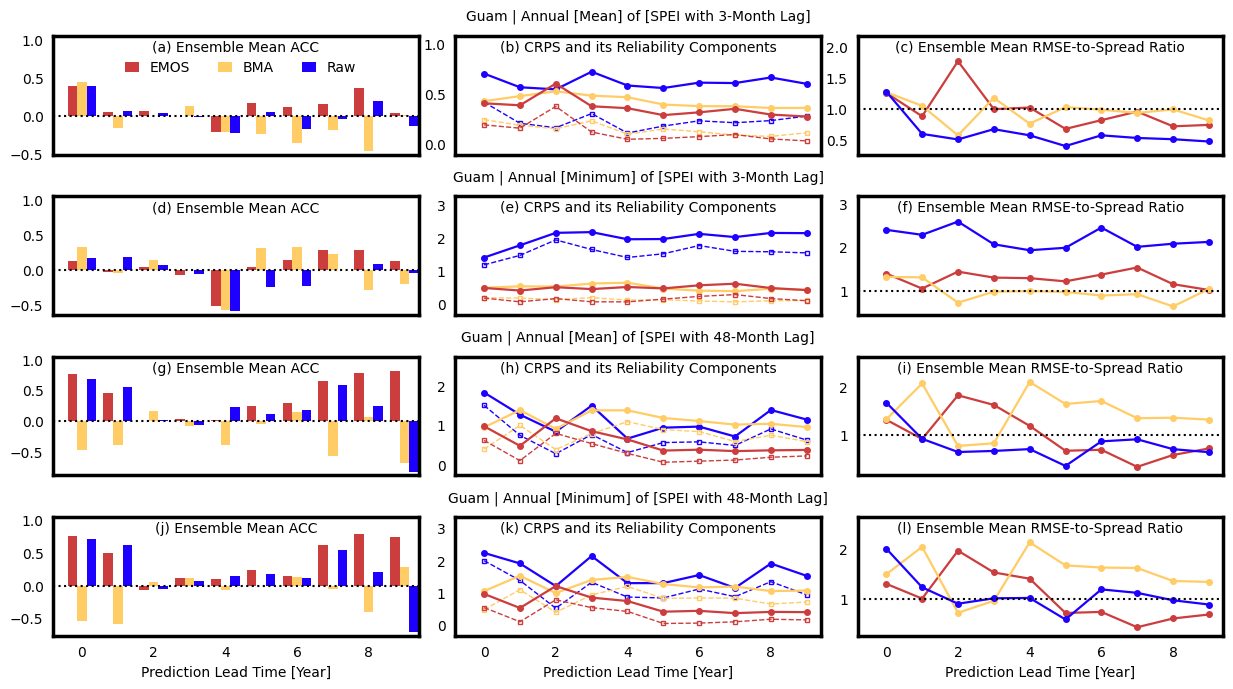

In [41]:
col_width = 3.9
row_height = 1.5
varnames = ['Guam_SPEI_03_mean', 'Guam_SPEI_03_min', 'Guam_SPEI_48_mean', 'Guam_SPEI_48_min'] # ]
title_names = []
for name_ in varnames:
    title_names.append(vars_verif[name_])

color_list = [red, orange, blue,]
fig, metrics = verify_variables_grid(
    varnames, sources, ds_target, years_verif, 
    col_width=col_width, row_height=row_height, 
    title_names=title_names, color_list=color_list, show_legend=False)

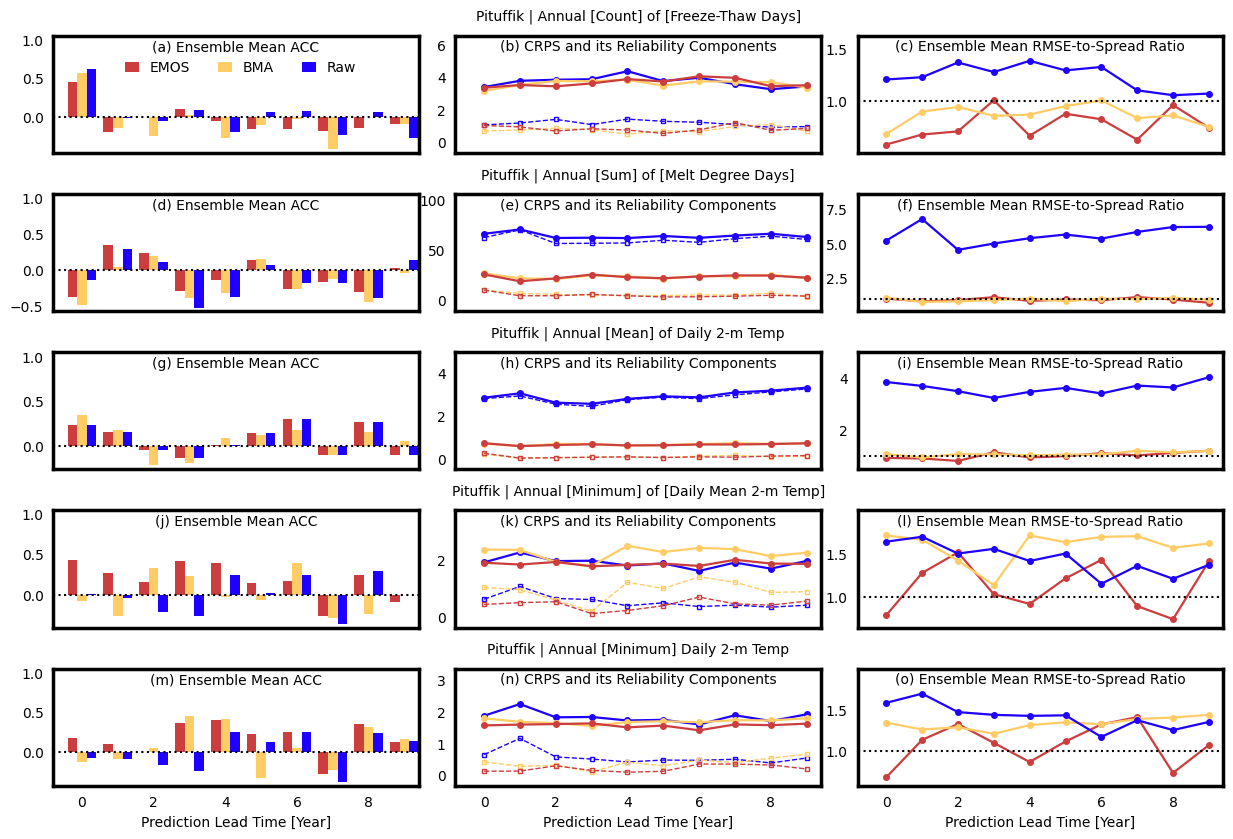

In [42]:
col_width = 3.9
row_height = 1.5
varnames = ['Pituffik_FT_days', 'Pituffik_MDD', 'Pituffik_simple_T2_1d_mean', 'Pituffik_simple_T2_1d_min', 'Pituffik_simple_T2_1h_min'] # ]
title_names = []
for name_ in varnames:
    title_names.append(vars_verif[name_])

color_list = [red, orange, blue,]
fig, metrics = verify_variables_grid(
    varnames, sources, ds_target, years_verif, 
    col_width=col_width, row_height=row_height, 
    title_names=title_names, color_list=color_list, show_legend=False)

/glade/derecho/scratch/ksha/tmp/ipykernel_5634/3940790470.py:50: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(ens, axis=-1)
/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/derecho/scratch/ksha/tmp/ipykernel_5634/3940790470.py:50: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(ens, axis=-1)
/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/derecho/scratch/ksha/tmp/ipykernel_5634/3940790470.py:50: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(ens, axis=-1)
/glade/work/ksha/miniconda3/envs/credit/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axi

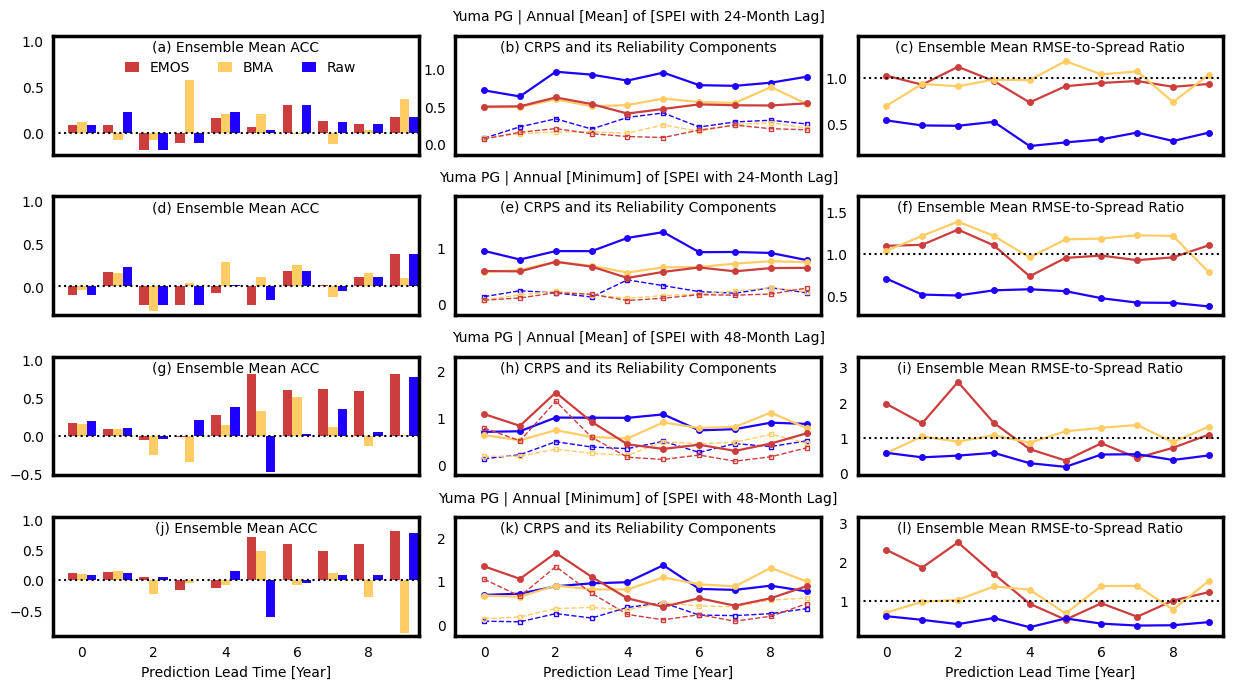

In [43]:
col_width = 3.9
row_height = 1.5
varnames = ['Yuma_PG_SPEI_24_mean', 'Yuma_PG_SPEI_24_min', 'Yuma_PG_SPEI_48_mean', 'Yuma_PG_SPEI_48_min'] # ]
title_names = []
for name_ in varnames:
    title_names.append(vars_verif[name_])

color_list = [red, orange, blue,]
fig, metrics = verify_variables_grid(
    varnames, sources, ds_target, years_verif, 
    col_width=col_width, row_height=row_height, 
    title_names=title_names, color_list=color_list, show_legend=False)

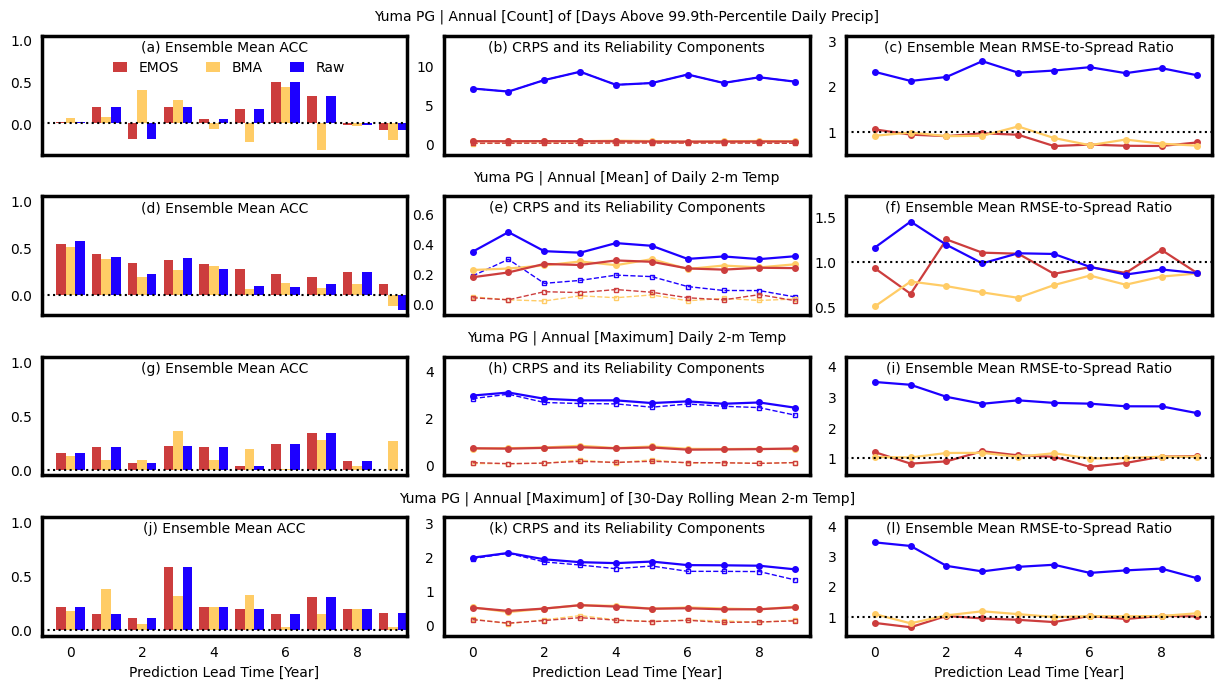

In [44]:
col_width = 3.9
row_height = 1.5
varnames = ['Yuma_PG_days_above_999p', 'Yuma_PG_simple_T2_1d_mean', 'Yuma_PG_simple_T2_1h_max', 'Yuma_PG_simple_T2_30d_max'] # ]
title_names = []
for name_ in varnames:
    title_names.append(vars_verif[name_])

color_list = [red, orange, blue,]
fig, metrics = verify_variables_grid(
    varnames, sources, ds_target, years_verif, 
    col_width=col_width, row_height=row_height, 
    title_names=title_names, color_list=color_list, show_legend=False)

In [35]:
vars_verif = {
    # ================ Fairbanks ================ #
    'Fairbanks_T2_1d_max': 'Fairbanks | Annual [Maximum] of [Daily Mean 2-m Temp]',
    'Fairbanks_T2_1h_max': 'Fairbanks | Annual [Maximum] Daily 2-m Temp',
    'Fairbanks_T2_30d_max': 'Fairbanks | Annual [Maximum] of [30-Day Rolling Mean 2-m Temp]',
    'Fairbanks_T2_7d_max': 'Fairbanks | Annual [Maximum] of [7-Day Rolling Mean 2-m Temp]',
    'Fairbanks_simple_T2_1d_mean': 'Fairbanks | Annual [Mean] Daily 2-m Temp',
    'Fairbanks_simple_T2_1d_min': 'Fairbanks | Annual [Minimum] of [Daily Mean 2-m Temp]',
    'Fairbanks_simple_T2_1h_min': 'Fairbanks | Annual [Minimum] Daily 2-m Temp',
    # ================ Fort Bragg ================ #
    'Fort_Bragg_SPEI_09_mean': 'Fort Bragg | Annual [Mean] of [SPEI with 9-Month Lag]',
    'Fort_Bragg_SPEI_09_min': 'Fort Bragg | Annual [Minimum] of [SPEI with 9-Month Lag]',
    'Fort_Bragg_SPEI_48_mean': 'Fort Bragg | Annual [Mean] of [SPEI with 48-Month Lag]',
    'Fort_Bragg_SPEI_48_min': 'Fort Bragg | Annual [Minimum] of [SPEI with 48-Month Lag]',
    'Fort_Bragg_simple_T2_1d_max': 'Fort Bragg | Annual [Maximum] of [Daily Mean 2-m Temp]',
    'Fort_Bragg_simple_T2_1d_mean': 'Fort Bragg | Annual [Mean] Daily 2-m Temp',
    'Fort_Bragg_simple_T2_1d_min': 'Fort Bragg | Annual [Minimum] of [Daily Mean 2-m Temp]',
    'Fort_Bragg_simple_T2_1h_max': 'Fort Bragg | Annual [Maximum] Daily 2-m Temp',
    'Fort_Bragg_simple_T2_1h_min': 'Fort Bragg | Annual [Minimum] Daily 2-m Temp',
    'Fort_Bragg_simple_T2_30d_max': 'Fort Bragg | Annual [Maximum] of [30-Day Rolling Mean 2-m Temp]',
    # ================ Guam ================ #
    'Guam_SPEI_03_mean': 'Guam | Annual [Mean] of [SPEI with 3-Month Lag]',
    'Guam_SPEI_03_min': 'Guam | Annual [Minimum] of [SPEI with 3-Month Lag]',
    'Guam_SPEI_48_mean': 'Guam | Annual [Mean] of [SPEI with 48-Month Lag]',
    'Guam_SPEI_48_min': 'Guam | Annual [Minimum] of [SPEI with 48-Month Lag]',
    'Guam_simple_T2_1d_max': 'Guam | Annual [Maximum] of [Daily Mean 2-m Temp]',
    'Guam_simple_T2_1d_mean': 'Guam | Annual [Mean] of Daily 2-m Temp',
    'Guam_simple_T2_1d_min': 'Guam | Annual [Minimum] of [Daily Mean 2-m Temp]',
    'Guam_simple_T2_1h_max': 'Guam | Annual [Maximum] Daily 2-m Temp',
    'Guam_simple_T2_1h_min': 'Guam | Annual [Minimum] Daily 2-m Temp',
    'Guam_simple_T2_30d_max': 'Guam | Annual [Maximum] of [30-Day Rolling Mean 2-m Temp]',
    # ================ Pituffik ================ #
    'Pituffik_FT_days': 'Pituffik | Annual [Count] of [Freeze-Thaw Days]',
    'Pituffik_MDD': 'Pituffik | Annual [Sum] of [Melt Degree Days]',
    'Pituffik_simple_T2_1d_max': 'Pituffik | Annual [Maximum] of [Daily Mean 2-m Temp]',
    'Pituffik_simple_T2_1d_mean': 'Pituffik | Annual [Mean] of Daily 2-m Temp',
    'Pituffik_simple_T2_1d_min': 'Pituffik | Annual [Minimum] of [Daily Mean 2-m Temp]',
    'Pituffik_simple_T2_1h_max': 'Pituffik | Annual [Maximum] Daily 2-m Temp',
    'Pituffik_simple_T2_1h_min': 'Pituffik | Annual [Minimum] Daily 2-m Temp',
    'Pituffik_simple_T2_30d_max': 'Pituffik | Annual [Maximum] of [30-Day Rolling Mean 2-m Temp]',
    # ================ Yuma PG ================ #
    'Yuma_PG_SPEI_24_mean': 'Yuma PG | Annual [Mean] of [SPEI with 24-Month Lag]',
    'Yuma_PG_SPEI_24_min': 'Yuma PG | Annual [Minimum] of [SPEI with 24-Month Lag]',
    'Yuma_PG_SPEI_48_mean': 'Yuma PG | Annual [Mean] of [SPEI with 48-Month Lag]',
    'Yuma_PG_SPEI_48_min': 'Yuma PG | Annual [Minimum] of [SPEI with 48-Month Lag]',
    'Yuma_PG_days_above_999p': 'Yuma PG | Annual [Count] of [Days Above 99.9th-Percentile Daily Precip]',
    'Yuma_PG_simple_T2_1d_max': 'Yuma PG | Annual [Maximum] of [Daily Mean 2-m Temp]',
    'Yuma_PG_simple_T2_1d_mean': 'Yuma PG | Annual [Mean] of Daily 2-m Temp',
    'Yuma_PG_simple_T2_1d_min': 'Yuma PG | Annual [Minimum] of [Daily Mean 2-m Temp]',
    'Yuma_PG_simple_T2_1h_max': 'Yuma PG | Annual [Maximum] Daily 2-m Temp',
    'Yuma_PG_simple_T2_1h_min': 'Yuma PG | Annual [Minimum] Daily 2-m Temp',
    'Yuma_PG_simple_T2_30d_max': 'Yuma PG | Annual [Maximum] of [30-Day Rolling Mean 2-m Temp]',
}

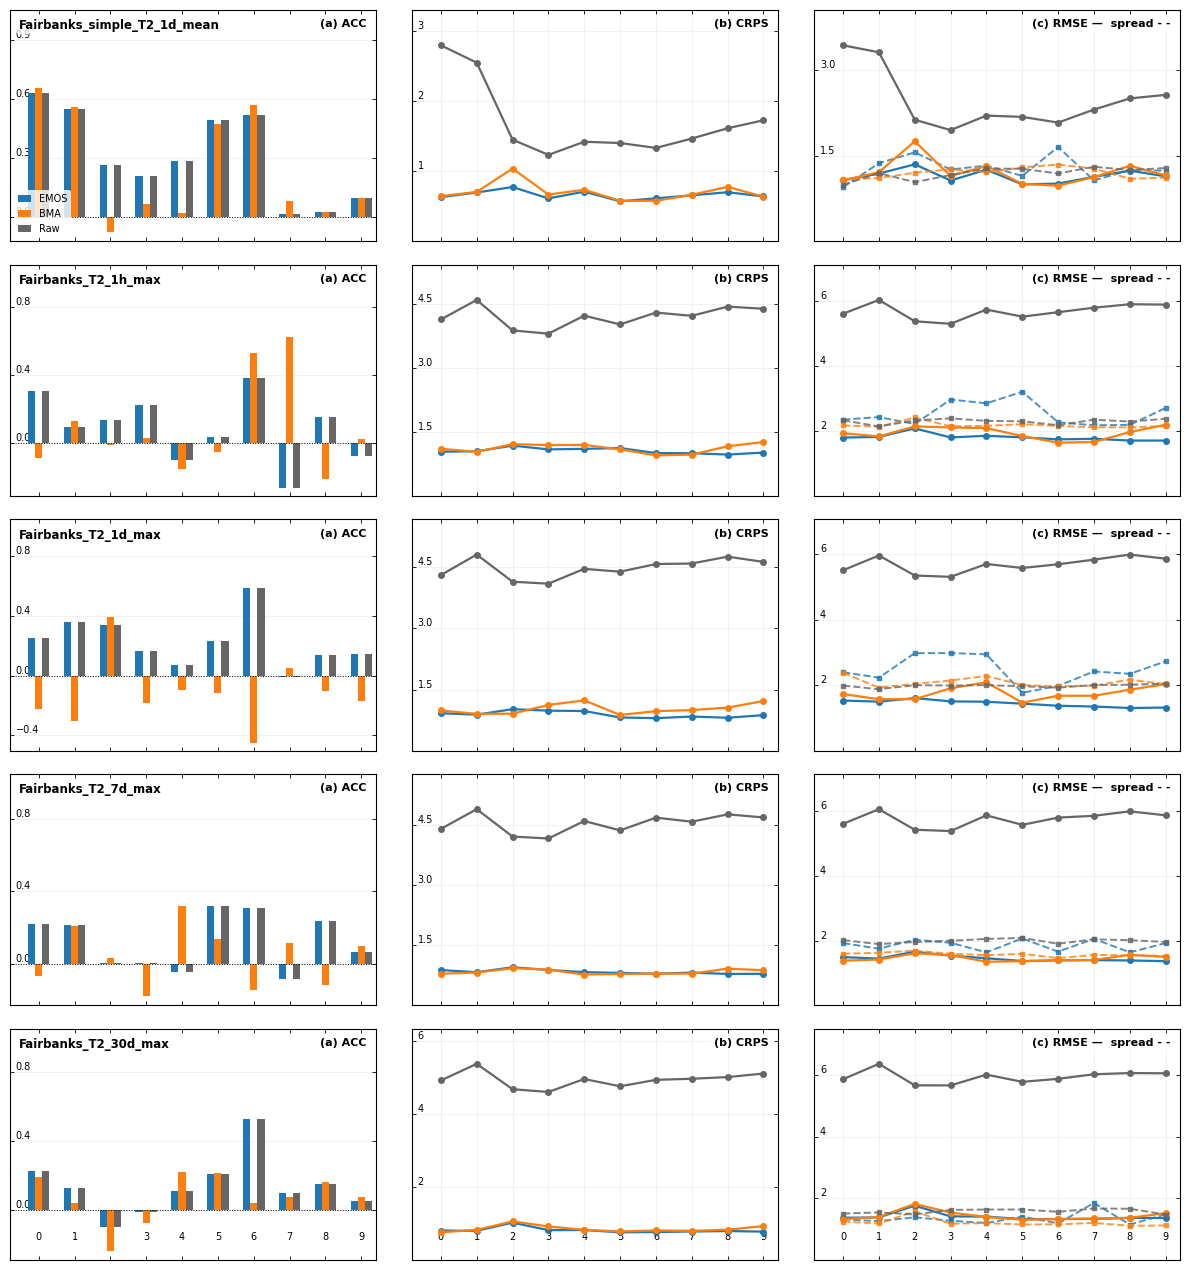

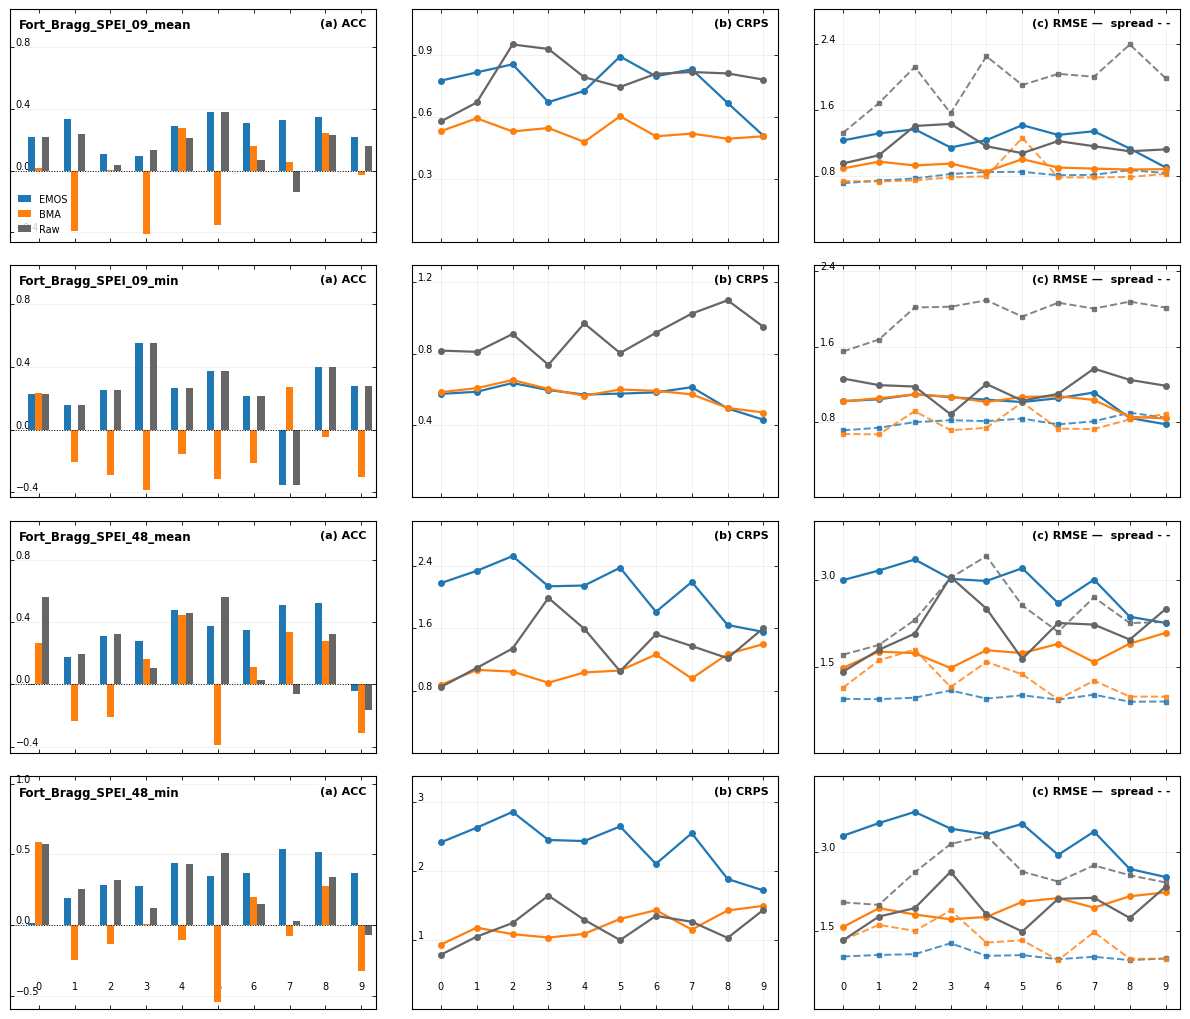

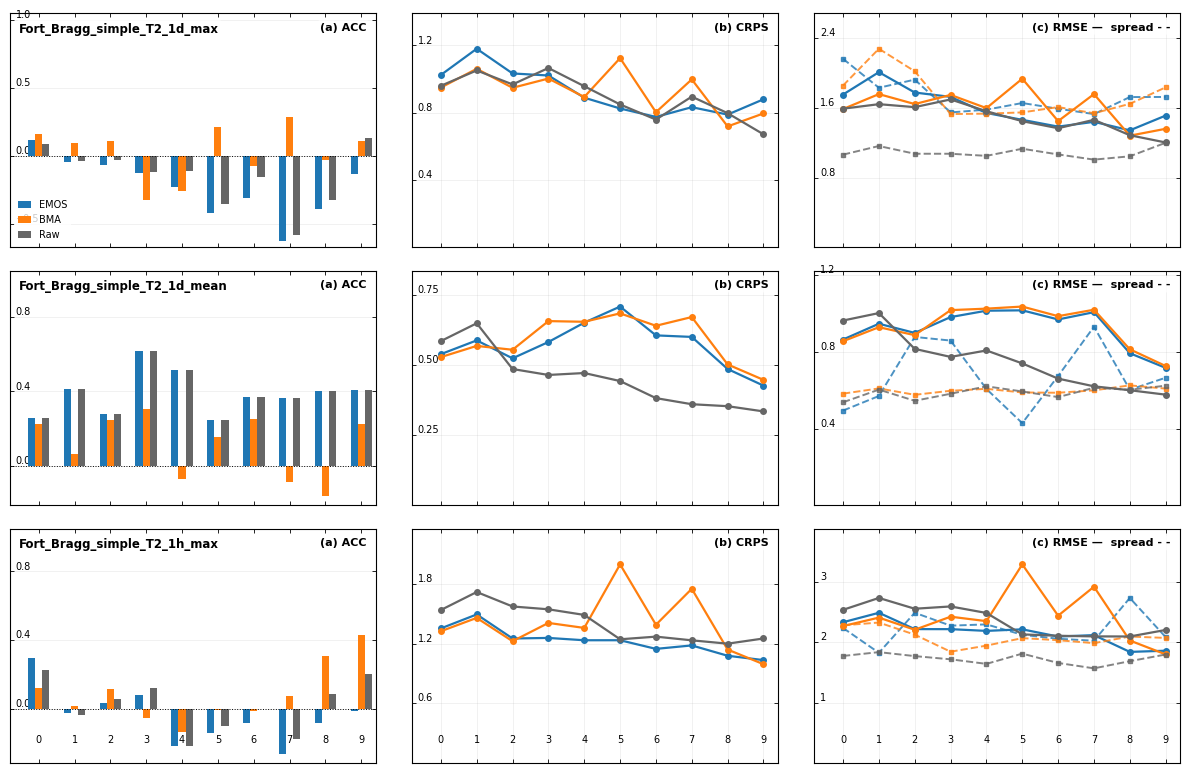

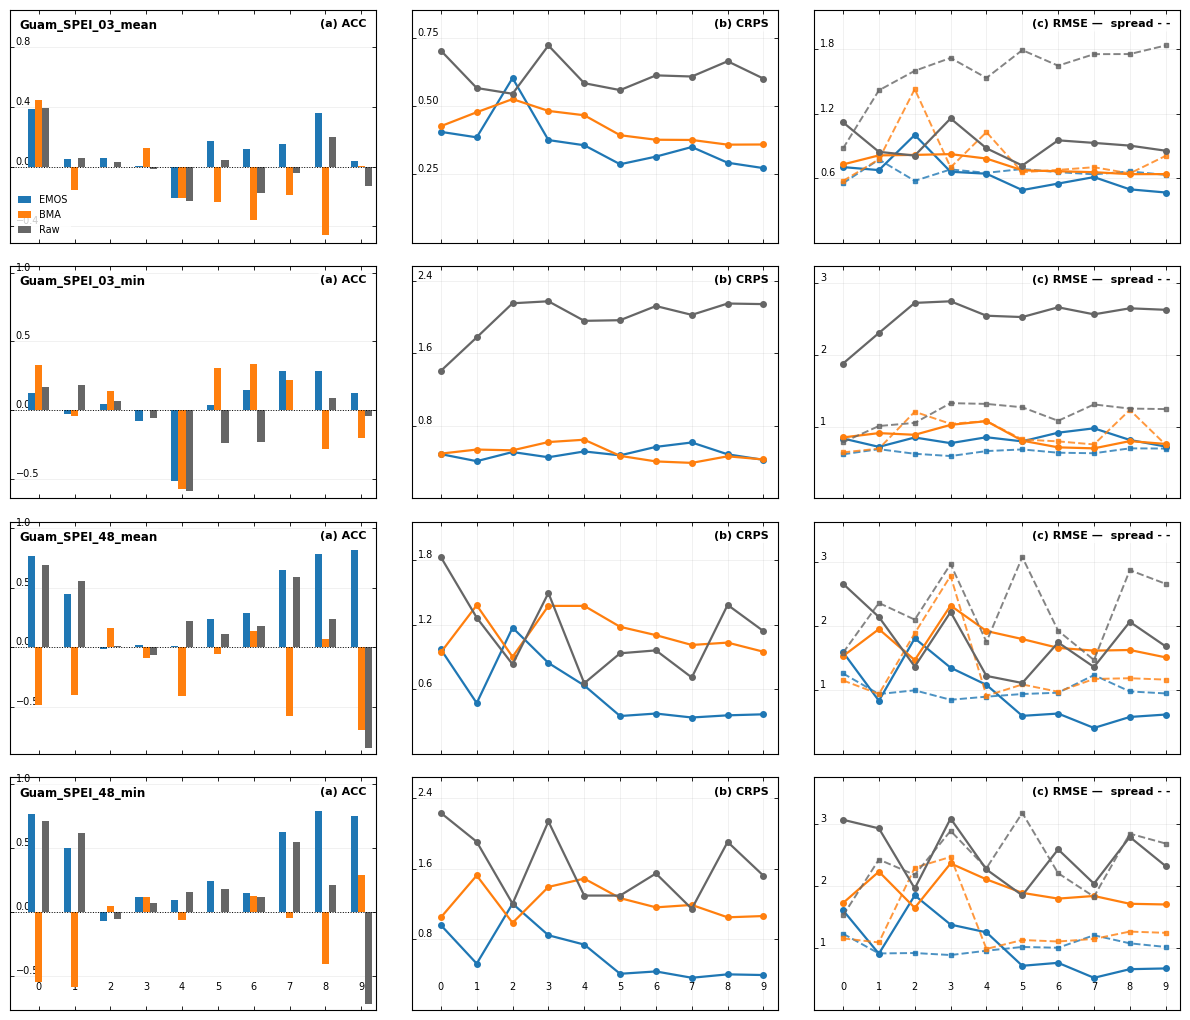

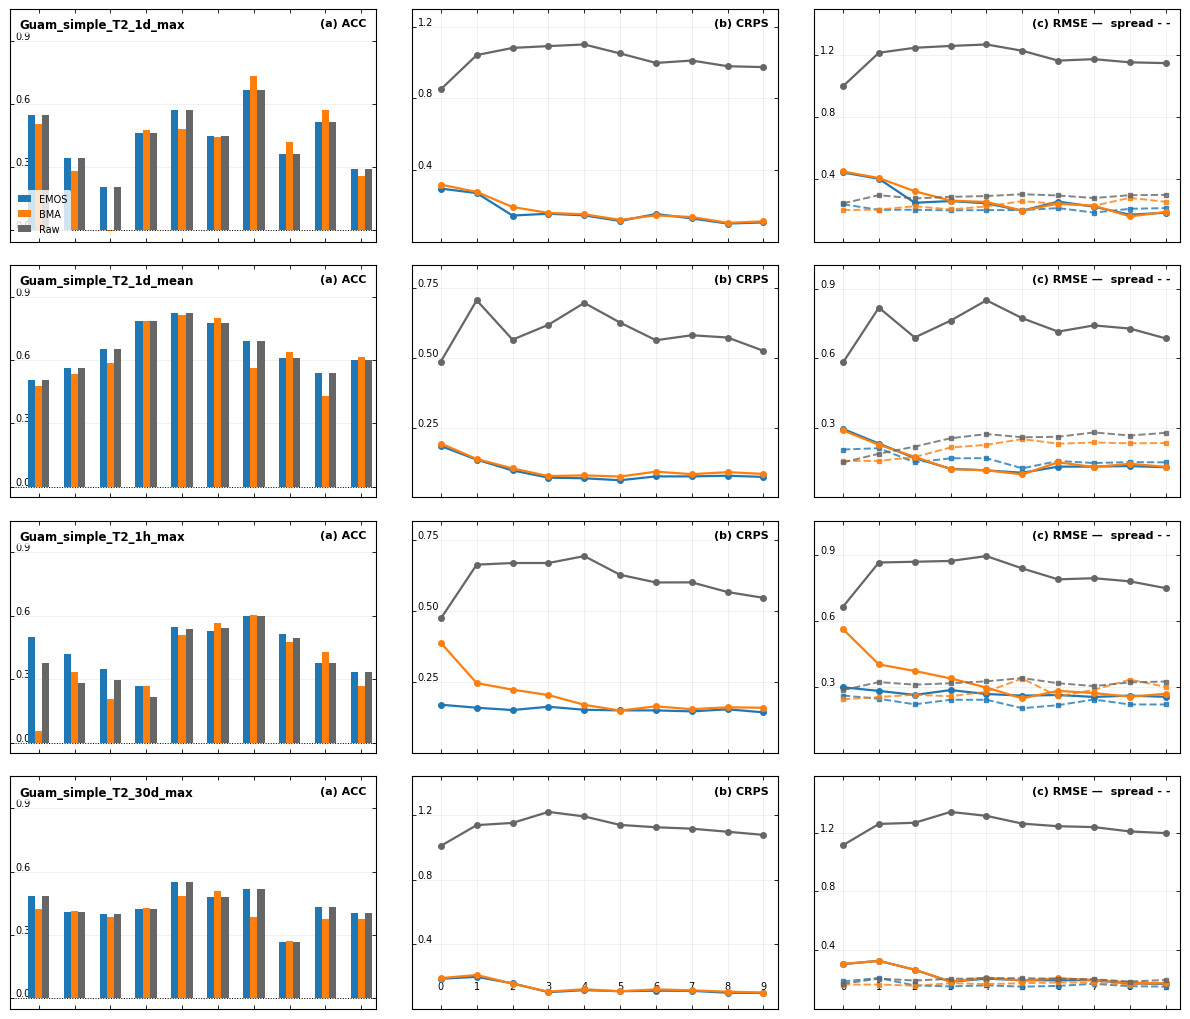

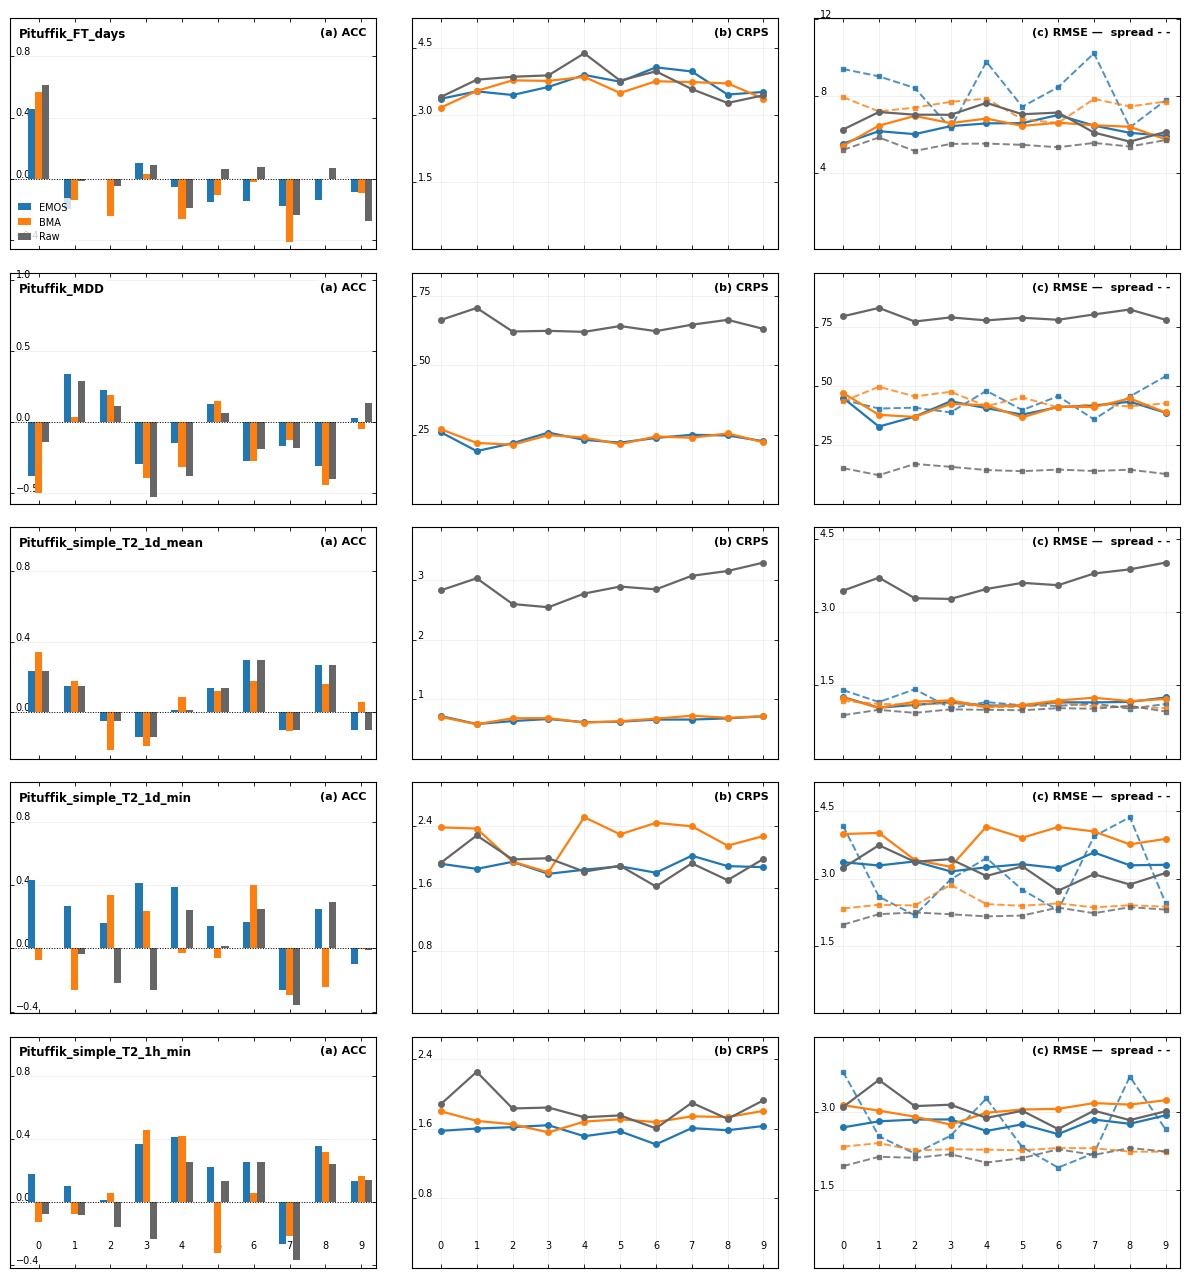

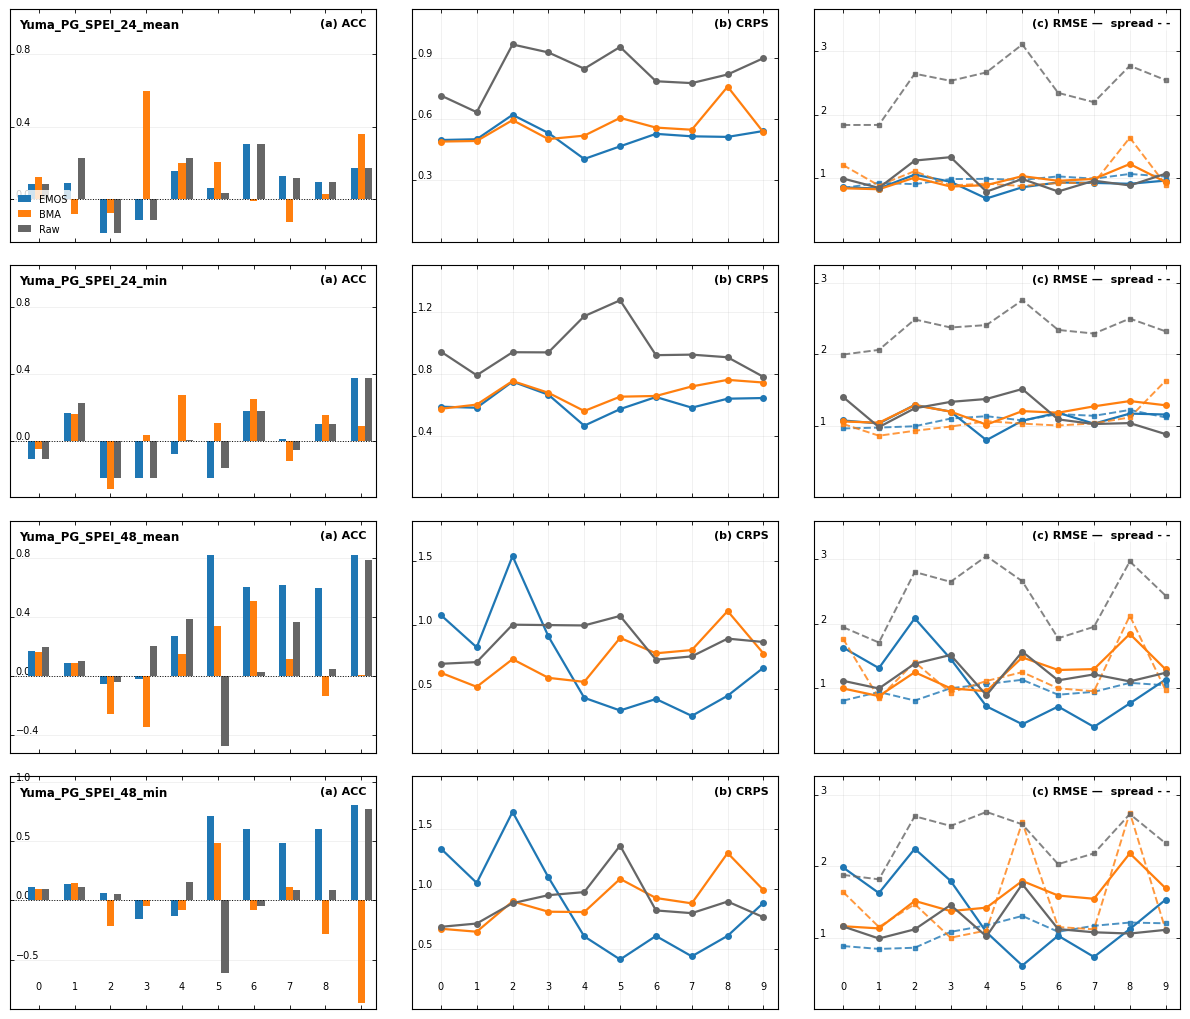

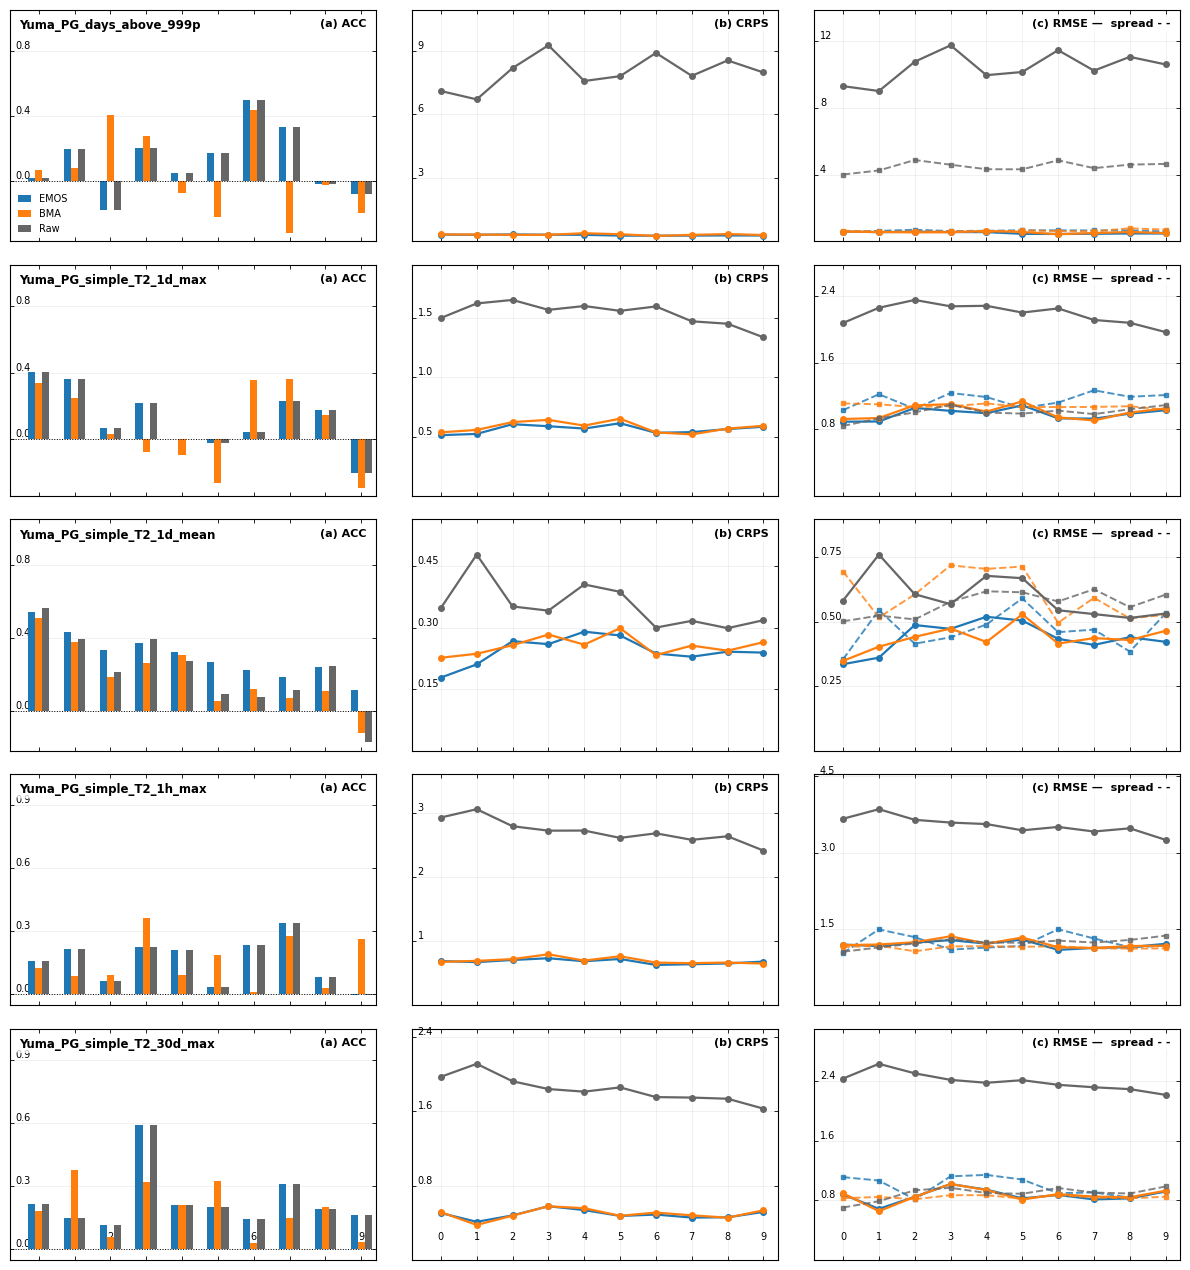

In [29]:


varnames = ['Fort_Bragg_SPEI_09_mean', 'Fort_Bragg_SPEI_09_min', 'Fort_Bragg_SPEI_48_mean', 'Fort_Bragg_SPEI_48_min']
fig, metrics = verify_variables_grid(varnames, sources, ds_target, ds_target_hist, years_verif)

varnames = ['Fort_Bragg_simple_T2_1d_max', 'Fort_Bragg_simple_T2_1d_mean', 'Fort_Bragg_simple_T2_1h_max']
fig, metrics = verify_variables_grid(varnames, sources, ds_target, ds_target_hist, years_verif)

varnames = ['Guam_SPEI_03_mean', 'Guam_SPEI_03_min', 'Guam_SPEI_48_mean', 'Guam_SPEI_48_min']
fig, metrics = verify_variables_grid(varnames, sources, ds_target, ds_target_hist, years_verif)

varnames = ['Guam_simple_T2_1d_max', 'Guam_simple_T2_1d_mean', 'Guam_simple_T2_1h_max', 'Guam_simple_T2_30d_max']
fig, metrics = verify_variables_grid(varnames, sources, ds_target, ds_target_hist, years_verif)

varnames = ['Pituffik_FT_days', 'Pituffik_MDD', 'Pituffik_simple_T2_1d_mean', 'Pituffik_simple_T2_1d_min','Pituffik_simple_T2_1h_min']
fig, metrics = verify_variables_grid(varnames, sources, ds_target, ds_target_hist, years_verif)

varnames = ['Yuma_PG_SPEI_24_mean', 'Yuma_PG_SPEI_24_min', 'Yuma_PG_SPEI_48_mean', 'Yuma_PG_SPEI_48_min', ]
fig, metrics = verify_variables_grid(varnames, sources, ds_target, ds_target_hist, years_verif)

varnames = ['Yuma_PG_days_above_999p', 'Yuma_PG_simple_T2_1d_max', 'Yuma_PG_simple_T2_1d_mean',  'Yuma_PG_simple_T2_1h_max', 'Yuma_PG_simple_T2_30d_max']
fig, metrics = verify_variables_grid(varnames, sources, ds_target, ds_target_hist, years_verif)

In [27]:
vars_verif = {
    # ================ Fairbanks ================ #
    'Fairbanks_T2_1d_max': 'Fairbanks | Annual [Maximum] of [Daily Mean 2-m Temp]',
    'Fairbanks_T2_1h_max': 'Fairbanks | Annual [Maximum] Daily 2-m Temp',
    'Fairbanks_T2_30d_max': 'Fairbanks | Annual [Maximum] of [30-Day Rolling Mean 2-m Temp]',
    'Fairbanks_T2_7d_max': 'Fairbanks | Annual [Maximum] of [7-Day Rolling Mean 2-m Temp]',
    'Fairbanks_simple_T2_1d_mean': 'Fairbanks | Annual [Mean] of Daily 2-m Temp',
    'Fairbanks_simple_T2_1d_min': 'Fairbanks | Annual [Minimum] of [Daily Mean 2-m Temp]',
    'Fairbanks_simple_T2_1h_min': 'Fairbanks | Annual [Minimum] Daily 2-m Temp',
    # ================ Fort Bragg ================ #
    'Fort_Bragg_SPEI_09_mean': 'Fort Bragg | Annual [Mean] of [SPEI with 9-Month Lag]',
    'Fort_Bragg_SPEI_09_min': 'Fort Bragg | Annual [Minimum] of [SPEI with 9-Month Lag]',
    'Fort_Bragg_SPEI_48_mean': 'Fort Bragg | Annual [Mean] of [SPEI with 48-Month Lag]',
    'Fort_Bragg_SPEI_48_min': 'Fort Bragg | Annual [Minimum] of [SPEI with 48-Month Lag]',
    'Fort_Bragg_simple_T2_1d_max': 'Fort Bragg | Annual [Maximum] of [Daily Mean 2-m Temp]',
    'Fort_Bragg_simple_T2_1d_mean': 'Fort Bragg | Annual [Mean] of Daily 2-m Temp',
    'Fort_Bragg_simple_T2_1d_min': 'Fort Bragg | Annual [Minimum] of [Daily Mean 2-m Temp]',
    'Fort_Bragg_simple_T2_1h_max': 'Fort Bragg | Annual [Maximum] Daily 2-m Temp',
    'Fort_Bragg_simple_T2_1h_min': 'Fort Bragg | Annual [Minimum] Daily 2-m Temp',
    'Fort_Bragg_simple_T2_30d_max': 'Fort Bragg | Annual [Maximum] of [30-Day Rolling Mean 2-m Temp]',
    # ================ Guam ================ #
    'Guam_SPEI_03_mean': 'Guam | Annual [Mean] of [SPEI with 3-Month Lag]',
    'Guam_SPEI_03_min': 'Guam | Annual [Minimum] of [SPEI with 3-Month Lag]',
    'Guam_SPEI_48_mean': 'Guam | Annual [Mean] of [SPEI with 48-Month Lag]',
    'Guam_SPEI_48_min': 'Guam | Annual [Minimum] of [SPEI with 48-Month Lag]',
    'Guam_simple_T2_1d_max': 'Guam | Annual [Maximum] of [Daily Mean 2-m Temp]',
    'Guam_simple_T2_1d_mean': 'Guam | Annual [Mean] of Daily 2-m Temp',
    'Guam_simple_T2_1d_min': 'Guam | Annual [Minimum] of [Daily Mean 2-m Temp]',
    'Guam_simple_T2_1h_max': 'Guam | Annual [Maximum] Daily 2-m Temp',
    'Guam_simple_T2_1h_min': 'Guam | Annual [Minimum] Daily 2-m Temp',
    'Guam_simple_T2_30d_max': 'Guam | Annual [Maximum] of [30-Day Rolling Mean 2-m Temp]',
    # ================ Pituffik ================ #
    'Pituffik_FT_days': 'Pituffik | Annual [Count] of [Freeze-Thaw Days]',
    'Pituffik_MDD': 'Pituffik | Annual [Sum] of [Melt Degree Days]',
    'Pituffik_simple_T2_1d_max': 'Pituffik | Annual [Maximum] of [Daily Mean 2-m Temp]',
    'Pituffik_simple_T2_1d_mean': 'Pituffik | Annual [Mean] of Daily 2-m Temp',
    'Pituffik_simple_T2_1d_min': 'Pituffik | Annual [Minimum] of [Daily Mean 2-m Temp]',
    'Pituffik_simple_T2_1h_max': 'Pituffik | Annual [Maximum] Daily 2-m Temp',
    'Pituffik_simple_T2_1h_min': 'Pituffik | Annual [Minimum] Daily 2-m Temp',
    'Pituffik_simple_T2_30d_max': 'Pituffik | Annual [Maximum] of [30-Day Rolling Mean 2-m Temp]',
    # ================ Yuma PG ================ #
    'Yuma_PG_SPEI_24_mean': 'Yuma PG | Annual [Mean] of [SPEI with 24-Month Lag]',
    'Yuma_PG_SPEI_24_min': 'Yuma PG | Annual [Minimum] of [SPEI with 24-Month Lag]',
    'Yuma_PG_SPEI_48_mean': 'Yuma PG | Annual [Mean] of [SPEI with 48-Month Lag]',
    'Yuma_PG_SPEI_48_min': 'Yuma PG | Annual [Minimum] of [SPEI with 48-Month Lag]',
    'Yuma_PG_days_above_999p': 'Yuma PG | Annual [Count] of [Days Above 99.9th-Percentile Daily Precip]',
    'Yuma_PG_simple_T2_1d_max': 'Yuma PG | Annual [Maximum] of [Daily Mean 2-m Temp]',
    'Yuma_PG_simple_T2_1d_mean': 'Yuma PG | Annual [Mean] of Daily 2-m Temp',
    'Yuma_PG_simple_T2_1d_min': 'Yuma PG | Annual [Minimum] of [Daily Mean 2-m Temp]',
    'Yuma_PG_simple_T2_1h_max': 'Yuma PG | Annual [Maximum] Daily 2-m Temp',
    'Yuma_PG_simple_T2_1h_min': 'Yuma PG | Annual [Minimum] Daily 2-m Temp',
    'Yuma_PG_simple_T2_30d_max': 'Yuma PG | Annual [Maximum] of [30-Day Rolling Mean 2-m Temp]',
}

In [32]:
fig_keys = {
    'dpi': 100, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

In [30]:
# varname_list = list(vars_verif.keys())
# for var_ in varname_list:
#     SOURCES = {
#         'BMA': pick_source(var_, ds_calib_BMA, ds_dress_BMA),
#         'EMOS': pick_source(var_, ds_calib_EMOS, ds_dress_EMOS),
#         'Raw': ('ensemble', ds_raw_pred),
#     }
    
#     fig, metrics = verify_variable(var_, SOURCES, ds_target, ds_target_hist, years_verif, figsize=(13, 13), title=vars_verif[var_])
#     fig.savefig(f'/glade/u/home/ksha/W2CC-base/figures/{var_}.png', format='png', **fig_keys)

In [35]:
vars_verif = {
    # ================ Fort Bragg ================ #
    'Fort_Bragg_PRECT_1d_max': 'Fort Bragg | Annual [Maximum] of [Daily Precip]',
    'Fort_Bragg_PRECT_3d_max': 'Fort Bragg | Annual [Maximum] of [3-Day Rolling Mean Precip]',
    'Fort_Bragg_PRECT_5d_max': 'Fort Bragg | Annual [Maximum] of [5-Day Rolling Mean Precip]',
    'Fort_Bragg_simple_PRECT_30d': 'Fort Bragg | Annual [Maximum] of [30-Day Rolling Mean Precip]',
    'Fort_Bragg_simple_PRECT_max': 'Fort Bragg | Annual [Maximum] of [Daily Precip]',
    'Fort_Bragg_simple_PRECT_mean': 'Fort Bragg | Annual [Mean] of [Daily Precip]',
    # ================ Guam ================ #
    'Guam_simple_PRECT_30d': 'Guam | Annual [Maximum] of [30-Day Rolling Mean Precip]',
    'Guam_simple_PRECT_max': 'Guam | Annual [Maximum] of [Daily Precip]',
    'Guam_simple_PRECT_mean': 'Guam | Annual [Mean] of [Daily Precip]',
    # ================ Pituffik ================ #
    'Pituffik_simple_PRECT_30d': 'Pituffik | Annual [Maximum] of [30-Day Rolling Mean Precip]',
    'Pituffik_simple_PRECT_max': 'Pituffik | Annual [Maximum] of [Daily Precip]',
    'Pituffik_simple_PRECT_mean': 'Pituffik | Annual [Mean] of [Daily Precip]',
    # ================ Yuma PG ================ #
    'Yuma_PG_PRECT_1d_max': 'Yuma PG | Annual [Maximum] of [Daily Precip]',
    'Yuma_PG_PRECT_7d_max': 'Yuma PG | Annual [Maximum] of [7-Day Rolling Mean Precip]',
    'Yuma_PG_simple_PRECT_30d': 'Yuma PG | Annual [Maximum] of [30-Day Rolling Mean Precip]',
    'Yuma_PG_simple_PRECT_max': 'Yuma PG | Annual [Maximum] of [Daily Precip]',
    'Yuma_PG_simple_PRECT_mean': 'Yuma PG | Annual [Mean] of [Daily Precip]',
}

In [31]:
# varname_list = list(vars_verif.keys())
# for var_ in varname_list:
#     SOURCES = {
#         'BMA': pick_source(var_, ds_calib_BMA, ds_dress_BMA),
#         'EMOS': pick_source(var_, ds_calib_EMOS, ds_dress_EMOS),
#         'Raw': ('ensemble', ds_raw_pred),
#     }
    
#     fig, metrics = verify_variable(var_, SOURCES, ds_target, ds_target_hist, years_verif, figsize=(13, 13), title=vars_verif[var_])
#     fig.savefig(f'/glade/u/home/ksha/W2CC-base/figures/{var_}.png', format='png', **fig_keys)